In [1]:
from typing import Sequence
import numpy as np
import pandas as pd
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from sklearn import datasets
from sklearn.model_selection import train_test_split
from keras.metrics import Precision, Recall
from sklearn.metrics import confusion_matrix, precision_score, recall_score

In [201]:
buenos_rematesdf = pd.read_csv("C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\dataset\\buenos\\rematesBUENOS2.txt")
malos_rematesdf = pd.read_csv("C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\dataset\\malos\\rematesMALOS2.txt")
print("el tamaño de :",len(buenos_rematesdf))
print("el tamaño de :",len(malos_rematesdf))
X = []
y = []
no_of_timesteps = 15

datasets = buenos_rematesdf.iloc[:,1:].values
#print(datasets)
n_samples = len(datasets)
#print(n_samples)

for i in range(no_of_timesteps, n_samples):
    X.append(datasets[i-no_of_timesteps:i,:])
    y.append(1)

datasets = malos_rematesdf.iloc[:,1:].values
n_samples = len(datasets)
#print(n_samples)

for i in range(no_of_timesteps, n_samples):
    X.append(datasets[i-no_of_timesteps:i,:])
    y.append(0)

X, y = np.array(X), np.array(y)
print("Total de Datos",len(X),len(y))
#print(X.shape, y.shape)

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# Dividir los datos en conjunto de entrenamiento+validación y conjunto de prueba
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Dividir los datos restantes en conjunto de entrenamiento y conjunto de validación
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)  # 0.25 x 0.8 = 0.2

# Imprimir las formas de los conjuntos resultantes
print("entrenamiento shape:", X_train.shape)
print("validacion shape:", X_val.shape)
print("prueba shape:", X_test.shape)
#print("y_train shape:", y_train.shape)
#print("y_val shape:", y_val.shape)
#print("y_test shape:", y_test.shape)

el tamaño de : 8399
el tamaño de : 4131
Total de Datos 12500 12500
entrenamiento shape: (9562, 15, 34)
validacion shape: (1688, 15, 34)
prueba shape: (1250, 15, 34)


In [202]:
print(len(X_train))
print(y_train.shape)
print(X_test.shape)

9562
(9562,)
(1250, 15, 34)


In [203]:
model2 = Sequential()
model2.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model2.add(Dropout(0.2))
model2.add(LSTM(units=40, return_sequences=True))
model2.add(Dropout(0.1))
model2.add(LSTM(units=40))
model2.add(Dropout(0.2))
model2.add(Dense(units=1, activation="sigmoid"))
model2.compile(optimizer="adam",  metrics=["accuracy"],loss="binary_crossentropy")

#model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))
#model.save("/content/drive/MyDrive/SIS330/Proyecto/lstm-model2.h5")

Epoch 1/70
299/299 [==============================] - 9s 16ms/step - loss: 0.6180 - accuracy: 0.6690 - val_loss: 0.5873 - val_accuracy: 0.6902
Epoch 2/70
299/299 [==============================] - 4s 14ms/step - loss: 0.5857 - accuracy: 0.6817 - val_loss: 0.5687 - val_accuracy: 0.7008
Epoch 3/70
299/299 [==============================] - 4s 14ms/step - loss: 0.5601 - accuracy: 0.6946 - val_loss: 0.5335 - val_accuracy: 0.7210
Epoch 4/70
299/299 [==============================] - 4s 14ms/step - loss: 0.5350 - accuracy: 0.7116 - val_loss: 0.5693 - val_accuracy: 0.7109
Epoch 5/70
299/299 [==============================] - 4s 15ms/step - loss: 0.5140 - accuracy: 0.7261 - val_loss: 0.5109 - val_accuracy: 0.7263
Epoch 6/70
299/299 [==============================] - 4s 15ms/step - loss: 0.4940 - accuracy: 0.7335 - val_loss: 0.5270 - val_accuracy: 0.7038
Epoch 7/70
299/299 [==============================] - 4s 15ms/step - loss: 0.4656 - accuracy: 0.7542 - val_loss: 0.4762 - val_accuracy: 0.7559

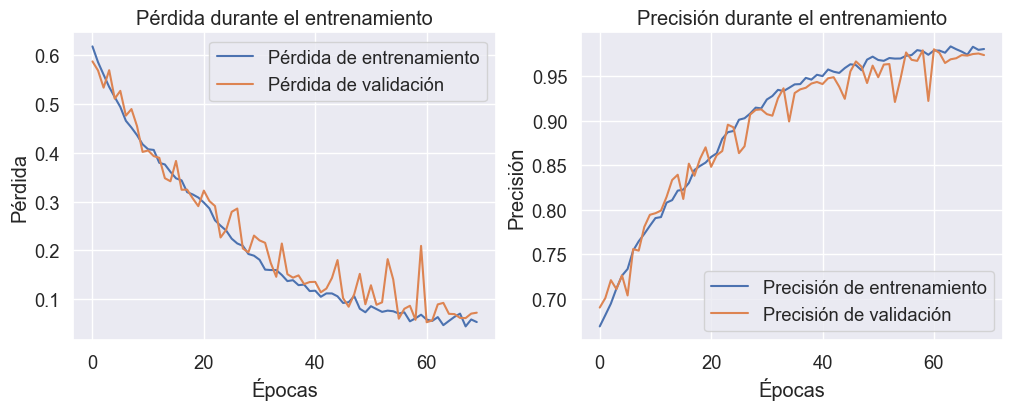

In [204]:
import matplotlib.pyplot as plt

history = model2.fit(X_train, y_train, epochs=70, batch_size=32, validation_data=(X_val, y_val))

# Graficar la pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Graficar la precisión
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.show()

In [191]:
evaluation = model2.evaluate(X_test, y_test)
print("Resultado de la evaluación:")
print("Loss:", evaluation[0])
print("Accuracy:", evaluation[1])
#print("Precision:", evaluation[2])
#print("Recall:", evaluation[3])

40/40 [==============================] - 0s 5ms/step - loss: 0.0515 - accuracy: 0.9832
Resultado de la evaluación:
Loss: 0.05154960975050926
Accuracy: 0.9832000136375427


In [205]:
model2.save("C:\\EV\\proyIA\\lstm15-mode973.h5")

c:\EV\proyIA\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [188]:
from keras.models import load_model

# Cargar el modelo
loaded_model = load_model("C:\\EV\\proyIA\\lstm-mode976.h5")

# Verificar que el modelo se ha cargado correctamente
loaded_model.summary()

Model: "sequential_11"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_33 (LSTM)              (None, 15, 50)            17000     
                                                                 
 dropout_33 (Dropout)        (None, 15, 50)            0         
                                                                 
 lstm_34 (LSTM)              (None, 15, 40)            14560     
                                                                 
 dropout_34 (Dropout)        (None, 15, 40)            0         
                                                                 
 lstm_35 (LSTM)              (None, 30)                8520      
                                                                 
 dropout_35 (Dropout)        (None, 30)                0         
                                                                 
 dense_11 (Dense)            (None, 1)               

40/40 [==============================] - 0s 4ms/step
Matriz de Confusión:


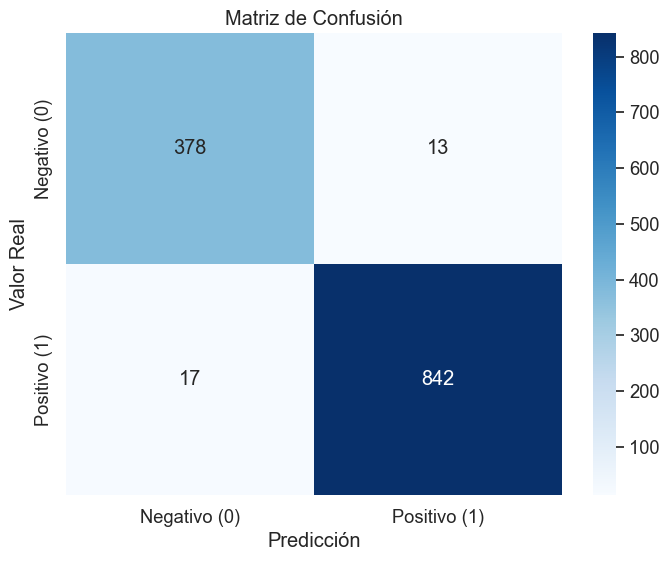


Métricas de Evaluación:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       391
           1       0.98      0.98      0.98       859

    accuracy                           0.98      1250
   macro avg       0.97      0.97      0.97      1250
weighted avg       0.98      0.98      0.98      1250



In [190]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = loaded_model.predict(X_test)
# Convertir las probabilidades continuas en clases binarias usando umbral de 0.5
y_pred_bin = (loaded_model.predict(X_test) > 0.5).astype("int32")
# Obtener la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_bin)
print("Matriz de Confusión:")
#print(conf_matrix)
# Definir etiquetas para los ejes
labels = ["Negativo (0)", "Positivo (1)"]

# Crear el heatmap de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Ajustar el tamaño de fuente para mejor legibilidad
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()
# Calcular otras métricas de evaluación
report = classification_report(y_test, y_pred_bin)

# Mostrar las métricas de evaluación
print("\nMétricas de Evaluación:")
print(report)

40/40 [==============================] - 0s 5ms/step
Matriz de Confusión:


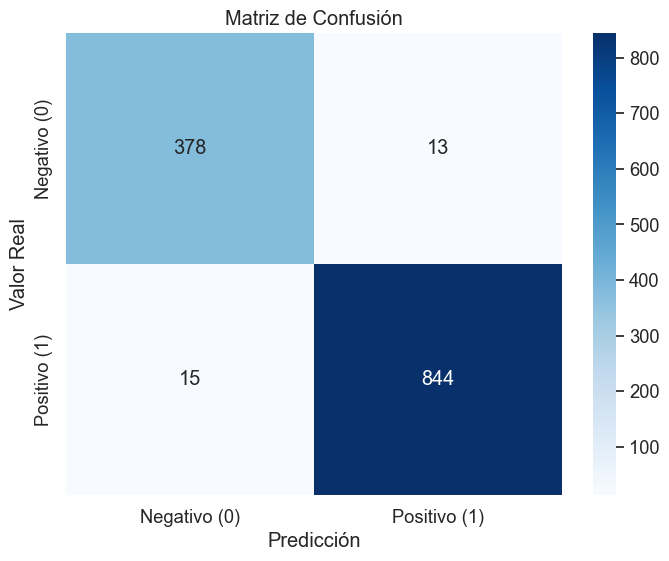


Métricas de Evaluación:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       391
           1       0.98      0.98      0.98       859

    accuracy                           0.98      1250
   macro avg       0.97      0.97      0.97      1250
weighted avg       0.98      0.98      0.98      1250



In [206]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model2.predict(X_test)
# Convertir las probabilidades continuas en clases binarias usando umbral de 0.5
y_pred_bin = (model2.predict(X_test) > 0.5).astype("int32")
# Obtener la matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred_bin)
print("Matriz de Confusión:")
#print(conf_matrix)
# Definir etiquetas para los ejes
labels = ["Negativo (0)", "Positivo (1)"]

# Crear el heatmap de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)  # Ajustar el tamaño de fuente para mejor legibilidad
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.title("Matriz de Confusión")
plt.show()
# Calcular otras métricas de evaluación
report = classification_report(y_test, y_pred_bin)

# Mostrar las métricas de evaluación
print("\nMétricas de Evaluación:")
print(report)

Tasa de Falsos Positivos (False Positive Rate): 0.03324808184143223


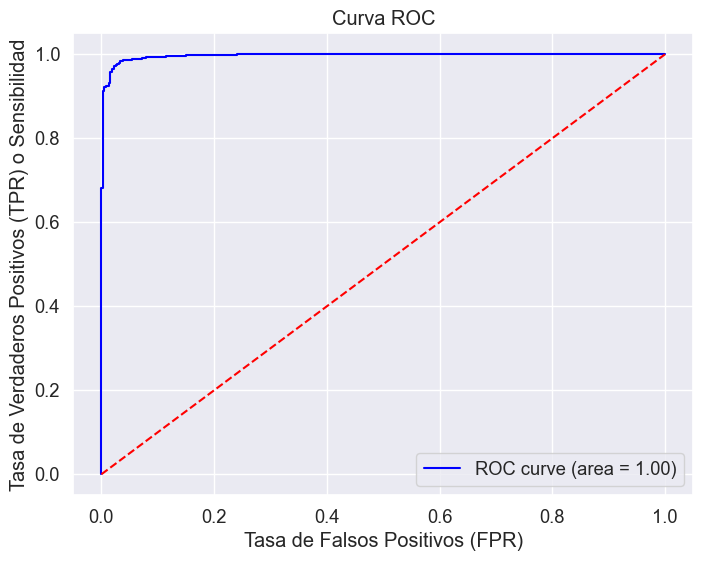

precision_score: 0.9847953216374269
recall: 0.980209545983702
F-Score: 0.9824970828471412


In [192]:
# Tasa de falsos positivos (False Positive Rate)
# Para calcular el FPR, necesitas tener los verdaderos negativos (True Negatives)
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, roc_auc_score, f1_score
conf_matrix = np.array(conf_matrix)
tn, fp, fn, tp = conf_matrix.ravel()
fpr = fp / (fp + tn)
print("Tasa de Falsos Positivos (False Positive Rate):", fpr)

# Curva ROC y área bajo la curva (AUC)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR) o Sensibilidad')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.show()

a=precision_score(y_test, y_pred_bin)
print("precision_score:",a)
recall= recall_score(y_test,y_pred_bin)
print("recall:",recall)
# F-Score
f_score = f1_score(y_test, y_pred_bin)
print("F-Score:", f_score)

In [117]:
print(X_test.shape)

(1250, 17, 34)


40/40 [==============================] - 0s 4ms/step


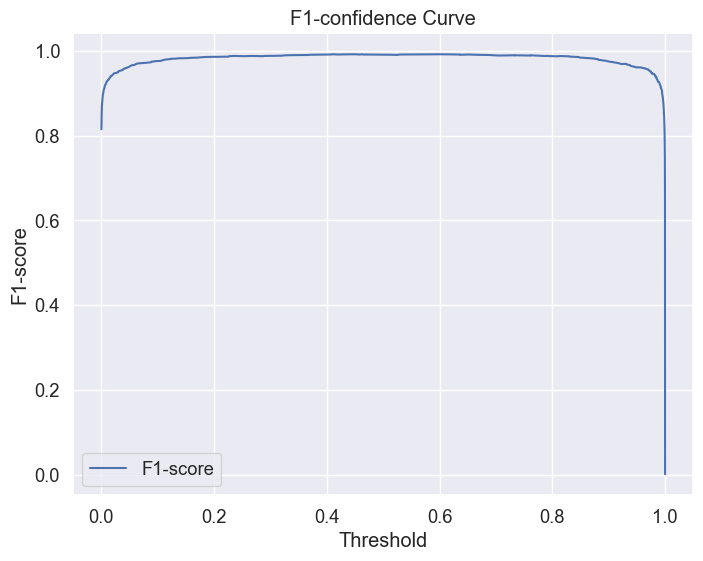

In [126]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Obtener las probabilidades de predicción
y_probs = model2.predict(X_test)

# Calcular la curva precision-recall y el área bajo la curva (AUC)
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
f1_scores = 2 * (precision * recall) / (precision + recall)
auc_score = auc(recall, precision)

# Graficar la curva F1-confidence
plt.figure(figsize=(8, 6))
plt.plot(thresholds, f1_scores[:-1], label='F1-score')
plt.xlabel('Threshold')
plt.ylabel('F1-score')
plt.title('F1-confidence Curve')
plt.legend()
plt.grid(True)
plt.show()